# ResNet18 Baseline - 1000 Samples

This notebook trains a ResNet18 model for document type classification using 1000 samples from the dataset.

**Model Architecture:** ResNet18
**Dataset Size:** 9000 images (balanced across 3 classes)  
**Training Configuration:**
- Batch size: 32
- Learning rate: 0.0001
- Epochs: 20
- Optimizer: Adam with weight decay 1e-4
- Dropout: 0.3


## Data Loading and Splitting

Load the dataset CSV file, sample 9000 images (if needed), and split into train/validation/test sets with stratified sampling to maintain class balance.


## Custom Dataset Class

Define a PyTorch Dataset class that loads images from file paths and applies transformations. Maps labels to numeric values (id_card=0, passport=1, driver_license=2).


In [1]:
import os
import sys

# Fix working directory issue - ensure we're in the project root
project_root = "/Users/roy-siftt/final-project"
if os.path.exists(project_root):
    os.chdir(project_root)
    print(f"Changed working directory to: {os.getcwd()}")
else:
    print(f"Warning: Project root {project_root} does not exist!")
    print(f"Current directory: {os.getcwd()}")

# Verify directory exists
if not os.path.exists(os.getcwd()):
    # Create it if it doesn't exist
    os.makedirs(os.getcwd(), exist_ok=True)
    print(f"Created directory: {os.getcwd()}")


Changed working directory to: /Users/roy-siftt/final-project


In [2]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
import os


SAMPLE_SIZE = 1000

df = pd.read_csv("/Users/roy-siftt/final-project/notebooks/document_type_classification/resnet18/data/dataset.csv")

print(f"Original dataset size: {len(df)} images")
print(f"\nOriginal distribution:")
print(df['label'].value_counts().sort_index())

# If we want a smaller dataset, sample proportionally
if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(df):
    df = df.groupby('label', group_keys=False).apply(
        lambda x: x.sample(n=min(len(x), int(SAMPLE_SIZE * len(x) / len(df))), random_state=42)
    ).reset_index(drop=True)
    print(f"\nDataset size after sampling: {len(df)} images")
    print(f"\nDistribution after sampling:")
    print(df['label'].value_counts().sort_index())




print(f"Original dataset size: {len(df)} images")
print(f"Columns: {df.columns.tolist()}")

# --- Create Group ID to prevent data leakage ---
# Try to use source_file if available, otherwise try to extract from filename
if 'source_file' in df.columns:
    df['group_id'] = df['source_file']
else:
    # Attempt to extract identifier if no explicit column (this is a guess, prefer using source_file)
    print("Warning: 'source_file' column missing. Using filename heuristics.")
    df['group_id'] = df['image_path'] 

print(f"Unique groups (distinct sources): {df['group_id'].nunique()}")

# --- Use GroupShuffleSplit (instead of train_test_split) ---
# Split 1: Train and (Test+Val)
splitter = GroupShuffleSplit(test_size=0.15, n_splits=1, random_state=42)
train_val_idxs, test_idxs = next(splitter.split(df, groups=df['group_id']))

train_val_df = df.iloc[train_val_idxs].reset_index(drop=True)
test_df = df.iloc[test_idxs].reset_index(drop=True)

# Split 2: Train and Val
splitter2 = GroupShuffleSplit(test_size=0.176, n_splits=1, random_state=42) # ~15% of total
train_idxs, val_idxs = next(splitter2.split(train_val_df, groups=train_val_df['group_id']))

train_df = train_val_df.iloc[train_idxs].reset_index(drop=True)
val_df = train_val_df.iloc[val_idxs].reset_index(drop=True)

print(f"\nFinal sizes - Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Original dataset size: 9000 images

Original distribution:
label
driver_license    3000
id_card           3000
passport          3000
Name: count, dtype: int64

Dataset size after sampling: 999 images

Distribution after sampling:
label
driver_license    333
id_card           333
passport          333
Name: count, dtype: int64
Original dataset size: 999 images
Columns: ['image_path', 'label']
Unique groups (distinct sources): 999

Final sizes - Train: 699, Val: 150, Test: 150


/var/folders/7v/16zlk2l53qq1v3dqsttk28zh0000gn/T/ipykernel_53920/121435809.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('label', group_keys=False).apply(


In [3]:
data_dir = "/Users/roy-siftt/final-project/notebooks/document_type_classification/resnet18/data"

# Create directory if it doesn't exist
os.makedirs(data_dir, exist_ok=True)

print(f"\n{'='*60}")
print(f"Final Split Summary:")
print(f"{'='*60}")

print(f"\nTrain Set: {len(train_df)} images")
print(train_df['label'].value_counts().sort_index())
print(f"   Total: {train_df['label'].value_counts().sum()}")

print(f"\nValidation Set: {len(val_df)} images")
print(val_df['label'].value_counts().sort_index())
print(f"   Total: {val_df['label'].value_counts().sum()}")

print(f"\nTest Set: {len(test_df)} images")
print(test_df['label'].value_counts().sort_index())
print(f"   Total: {test_df['label'].value_counts().sum()}")

print(f"\n{'='*60}")
print(f"Saving files to {data_dir}...")

# Save to the data directory
train_path = os.path.join(data_dir, "train.csv")
val_path = os.path.join(data_dir, "val.csv")
test_path = os.path.join(data_dir, "test.csv")

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

print(f"✓ Train saved to: {train_path}")
print(f"✓ Val saved to: {val_path}")
print(f"✓ Test saved to: {test_path}")
print(f"\nFiles saved successfully!")
print(f"{'='*60}")


Final Split Summary:

Train Set: 699 images
label
driver_license    229
id_card           236
passport          234
Name: count, dtype: int64
   Total: 699

Validation Set: 150 images
label
driver_license    54
id_card           46
passport          50
Name: count, dtype: int64
   Total: 150

Test Set: 150 images
label
driver_license    50
id_card           51
passport          49
Name: count, dtype: int64
   Total: 150

Saving files to /Users/roy-siftt/final-project/notebooks/document_type_classification/resnet18/data...
✓ Train saved to: /Users/roy-siftt/final-project/notebooks/document_type_classification/resnet18/data/train.csv
✓ Val saved to: /Users/roy-siftt/final-project/notebooks/document_type_classification/resnet18/data/val.csv
✓ Test saved to: /Users/roy-siftt/final-project/notebooks/document_type_classification/resnet18/data/test.csv

Files saved successfully!


## Data Augmentation and Transforms

Define image transformations for training (with strong augmentation) and validation/test (without augmentation). Uses ImageNet normalization statistics.


In [4]:
from torch.utils.data import Dataset
from PIL import Image
import torch

class DocumentDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

        # Normalize labels (lowercase + strip spaces)
        self.df['label'] = self.df['label'].str.lower().str.strip()

        # Label mapping
        self.label_map = {
            "id_card": 0,
            "passport": 1,
            "driver_license": 2
        }

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert("RGB")

        label_str = row['label']

        if label_str not in self.label_map:
            raise ValueError(f"Label '{label_str}' not found in label_map!")

        label = self.label_map[label_str]

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label)

## Create DataLoaders

Create PyTorch DataLoaders for train, validation, and test sets with appropriate batch sizes and shuffling.


In [5]:
import os

# Ensure working directory is correct before importing torchvision
project_root = "/Users/roy-siftt/final-project"
if os.path.exists(project_root):
    os.chdir(project_root)
    print(f"Working directory set to: {os.getcwd()}")

from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomRotation(15),
    
    # Adding blur - critical for making synthetic images look "realistic"
    transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)),
    
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    
    # Optional: 50% of the time convert to grayscale to avoid relying only on color
    transforms.RandomGrayscale(p=0.5), 

    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3)
])

# Transform for validation/test - without augmentation
val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])




Working directory set to: /Users/roy-siftt/final-project


## ResNet18 Model Definition

Define the ResNet18 classifier model. The model is trained from scratch (no pre-training). The final fully connected layer is replaced with a dropout layer followed by a linear layer for 3 classes.


In [6]:
from torch.utils.data import DataLoader
import os

# Base directory for the dataset
base_dir = "/Users/roy-siftt/final-project/notebooks/document_type_classification/resnet18"
data_dir = os.path.join(base_dir, "data")

# Load datasets with correct paths - need to update image paths to be relative to base_dir
train_df = pd.read_csv(os.path.join(data_dir, "train.csv"))
val_df = pd.read_csv(os.path.join(data_dir, "val.csv"))
test_df = pd.read_csv(os.path.join(data_dir, "test.csv"))

# Update image paths to be absolute paths
train_df['image_path'] = train_df['image_path'].apply(lambda x: os.path.join(base_dir, x))
val_df['image_path'] = val_df['image_path'].apply(lambda x: os.path.join(base_dir, x))
test_df['image_path'] = test_df['image_path'].apply(lambda x: os.path.join(base_dir, x))

# Use different transforms for train and val/test
train_dataset = DocumentDataset(train_df, train_transform)
val_dataset   = DocumentDataset(val_df, val_test_transform)
test_dataset  = DocumentDataset(test_df, val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Dataset sizes:")
print(f"   Train: {len(train_dataset)}")
print(f"   Val:   {len(val_dataset)}")
print(f"   Test:  {len(test_dataset)}")

Dataset sizes:
   Train: 699
   Val:   150
   Test:  150


## Visualize Sample Batch

Display a sample batch of training images to verify data loading and augmentation are working correctly.


In [7]:
import torch
import torch.nn as nn
from torchvision import models

class ResNet18Classifier(nn.Module):
    def __init__(self, num_classes=3, pretrained=True, dropout=0.5):
        super(ResNet18Classifier, self).__init__()
        
        # Load ResNet18 pre-trained on ImageNet
        if pretrained:
            self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        else:
            self.resnet = models.resnet18(weights=None)
        
        # Replace the final layer and add Dropout for regularization
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(num_features, num_classes)
        )
        
    def forward(self, x):
        return self.resnet(x)

## Verify Dataset Loading

Check that images and labels are being loaded correctly by printing sample paths and labels.


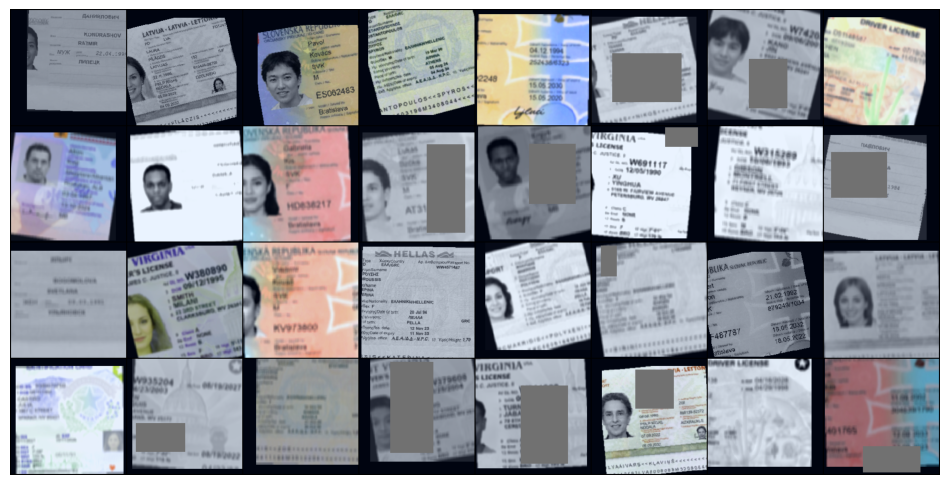

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision

def show_batch(loader):
    imgs, labels = next(iter(loader))
    grid = torchvision.utils.make_grid(imgs, nrow=8, normalize=True)
    plt.figure(figsize=(12,8))
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    plt.axis('off')

show_batch(train_loader)

## Training Setup and Execution

Initialize the model, loss function, and optimizer. Train the model for multiple epochs, evaluating on validation set after each epoch. Finally, evaluate on the test set and visualize training curves.


In [9]:
for i in range(10):
    print("PATH:", train_dataset.df.iloc[i]['image_path'])
    print("LABEL:", train_dataset.df.iloc[i]['label'])
    img, lbl = train_dataset[i]
    print("LOADER LABEL:", lbl)
    print("----")

PATH: /Users/roy-siftt/final-project/notebooks/document_type_classification/resnet18/images/06012.png
LABEL: driver_license
LOADER LABEL: tensor(2)
----
PATH: /Users/roy-siftt/final-project/notebooks/document_type_classification/resnet18/images/08477.png
LABEL: driver_license
LOADER LABEL: tensor(2)
----
PATH: /Users/roy-siftt/final-project/notebooks/document_type_classification/resnet18/images/06555.png
LABEL: driver_license
LOADER LABEL: tensor(2)
----
PATH: /Users/roy-siftt/final-project/notebooks/document_type_classification/resnet18/images/06970.png
LABEL: driver_license
LOADER LABEL: tensor(2)
----
PATH: /Users/roy-siftt/final-project/notebooks/document_type_classification/resnet18/images/07070.png
LABEL: driver_license
LOADER LABEL: tensor(2)
----
PATH: /Users/roy-siftt/final-project/notebooks/document_type_classification/resnet18/images/06346.png
LABEL: driver_license
LOADER LABEL: tensor(2)
----
PATH: /Users/roy-siftt/final-project/notebooks/document_type_classification/resnet

Using device: mps
Model: ResNet18
Number of parameters: 11,178,051
Learning rate: 0.0001
Dropout: 0.3

Starting training...


=== Initial Evaluation (Before Training) ===

Sample predictions (first 20):
  True: 2, Predicted: 1, ✗
  True: 0, Predicted: 1, ✗
  True: 0, Predicted: 1, ✗
  True: 0, Predicted: 1, ✗
  True: 2, Predicted: 1, ✗
  True: 1, Predicted: 1, ✓
  True: 0, Predicted: 1, ✗
  True: 0, Predicted: 1, ✗
  True: 1, Predicted: 1, ✓
  True: 2, Predicted: 1, ✗
  True: 2, Predicted: 1, ✗
  True: 1, Predicted: 1, ✓
  True: 1, Predicted: 1, ✓
  True: 1, Predicted: 1, ✓
  True: 0, Predicted: 1, ✗
  True: 0, Predicted: 1, ✗
  True: 1, Predicted: 1, ✓
  True: 2, Predicted: 1, ✗
  True: 2, Predicted: 1, ✗
  True: 2, Predicted: 1, ✗

Confusion Matrix:
[[  1 235   0]
 [  0 234   0]
 [  0 229   0]]

Train Acc (before): 0.3362
Val Acc (before):   0.3333

=== Epoch 1/20 ===


Training: 100%|██████████| 22/22 [00:16<00:00,  1.34it/s]


Train Loss: 1.4501 | Train Acc: 0.3505
Val   Loss: 1.1100 | Val   Acc: 0.3067
✓ New best validation accuracy: 0.3067 - Model saved

=== Epoch 2/20 ===


Training: 100%|██████████| 22/22 [00:17<00:00,  1.26it/s]


Train Loss: 1.0020 | Train Acc: 0.4692
Val   Loss: 0.7374 | Val   Acc: 0.5600
✓ New best validation accuracy: 0.5600 - Model saved

=== Epoch 3/20 ===


...

Train Loss: 0.3069 | Train Acc: 0.8956
Val   Loss: 0.1562 | Val   Acc: 0.9933
⚠ No improvement for 3/5 epochs

=== Epoch 11/20 ===


Training: 100%|██████████| 22/22 [00:15<00:00,  1.46it/s]


Train Loss: 0.3730 | Train Acc: 0.8612
Val   Loss: 0.5067 | Val   Acc: 0.7067
⚠ No improvement for 4/5 epochs

=== Epoch 12/20 ===


Training: 100%|██████████| 22/22 [00:15<00:00,  1.38it/s]


Train Loss: 0.1695 | Train Acc: 0.9456
Val   Loss: 0.1676 | Val   Acc: 0.9267
⚠ No improvement for 5/5 epochs

Early Stopping triggered!
Best validation accuracy: 0.9933 at epoch 7
✓ Restored best model weights

FINAL EVALUATION ON TEST SET (Never seen during training)

Sample predictions (first 20):
  True: 2, Predicted: 1, ✗
  True: 2, Predicted: 2, ✓
  True: 2, Predicted: 2, ✓
  True: 2, Predicted: 2, ✓
  True: 2, Predicted: 2, ✓
  True: 2, Predicted: 2, ✓
  True: 2, Predicted: 2, ✓
  True: 2, Predicted: 2, ✓
  True: 2, Predicted: 2, ✓
  True: 2, Predicted: 2, ✓
  True: 2, Predicted: 2, ✓
  True: 2, Predicted: 2, ✓
  True: 2, Predicted: 2, ✓
  True: 2, Predicted: 2, ✓
  True: 2, Predicted: 2, ✓
  True: 2, Predicted: 2, ✓
  True: 2, Predicted: 2, ✓
  True: 2, Predicted: 2, ✓
  True: 2, Predicted: 2, ✓
  True: 2, Predicted: 2, ✓

Confusion Matrix:
[[32 19  0]
 [ 0 49  0]
 [ 0  1 49]]

Final Test Accuracy: 0.8667
Final Test Loss: 0.2187


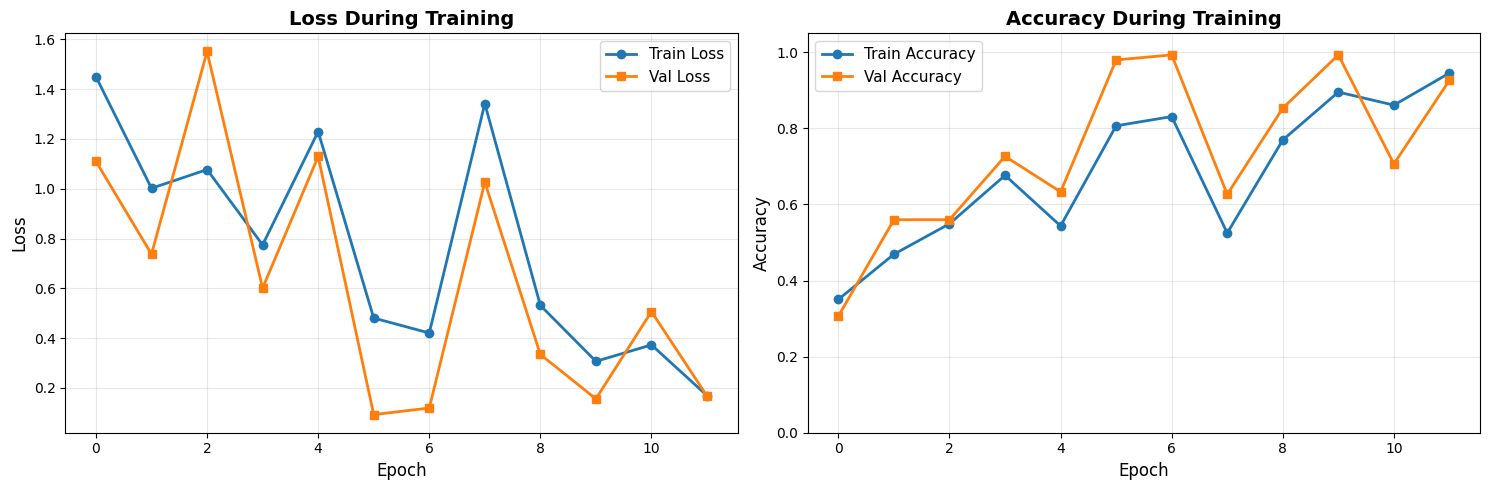


Training Summary:
Best Train Accuracy: 0.9456 (Epoch 12)
Best Val Accuracy:   0.9933 (Epoch 7)
Early Stopping Best Val Accuracy: 0.9933 (Epoch 7)
Final Test Accuracy: 0.8667
Total Epochs Trained: 12
Training stopped early due to no improvement (patience: 5)

Successfully observed real learning process!


In [10]:
import torch
from torch.optim import Adam
import torch.nn as nn
from tqdm import tqdm
import numpy as np

# Device selection: CUDA (NVIDIA GPU) -> MPS (Apple Silicon GPU) -> CPU
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = "mps"  # Apple Silicon GPU (M1/M2/M3)
else:
    device = "cpu"

# Create ResNet18 model 
model = ResNet18Classifier(num_classes=3, pretrained=False, dropout=0.3).to(device)

criterion = nn.CrossEntropyLoss()

# Learning rate for model learning from scratch
optimizer = Adam(model.parameters(),lr=0.0001, weight_decay=1e-4)

print(f"Using device: {device}")
print(f"Model: ResNet18")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Learning rate: {optimizer.param_groups[0]['lr']}")
print(f"Dropout: 0.3")
print("\nStarting training...\n")

def evaluate(loader, verbose=False):
    model.eval()
    total = 0
    correct = 0
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    avg_loss = total_loss / len(loader)
    
    if verbose:
        # Detailed check - what is the model predicting?
        print(f"\nSample predictions (first 20):")
        for i in range(min(20, len(all_preds))):
            print(f"  True: {all_labels[i]}, Predicted: {all_preds[i]}, {'✓' if all_preds[i] == all_labels[i] else '✗'}")
        
        # Confusion matrix
        from sklearn.metrics import confusion_matrix
        cm = confusion_matrix(all_labels, all_preds)
        print(f"\nConfusion Matrix:")
        print(cm)
    
    return accuracy, avg_loss

# Initial evaluation before training
print("\n" + "="*60)
print("=== Initial Evaluation (Before Training) ===")
print("="*60)
initial_train_acc, initial_train_loss = evaluate(train_loader, verbose=True)
initial_val_acc, initial_val_loss = evaluate(val_loader)
print(f"\nTrain Acc (before): {initial_train_acc:.4f}")
print(f"Val Acc (before):   {initial_val_acc:.4f}")
print("="*60)

# Track training progress - save performance at each epoch
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

# Early Stopping parameters
early_stopping_patience = 5  # Number of epochs to wait before stopping
early_stopping_min_delta = 0.001  # Minimum change to qualify as an improvement
best_val_acc = 0.0
patience_counter = 0
best_model_state = None
best_epoch = 0

num_epochs = 20  # Maximum epochs (may stop earlier due to early stopping)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0

    print(f"\n=== Epoch {epoch+1}/{num_epochs} ===")

    # tqdm for nice progress bar
    for imgs, labels in tqdm(train_loader, desc="Training"):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation calculations
    train_accuracy, train_loss = evaluate(train_loader)
    val_accuracy, val_loss = evaluate(val_loader)
    
    # Save to history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_accuracy)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_accuracy)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_accuracy:.4f}")
    
    # Early Stopping logic
    if val_accuracy > best_val_acc + early_stopping_min_delta:
        # Improvement detected
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        patience_counter = 0
        # Save best model state
        best_model_state = model.state_dict().copy()
        print(f"✓ New best validation accuracy: {best_val_acc:.4f} - Model saved")
    else:
        # No improvement
        patience_counter += 1
        print(f"⚠ No improvement for {patience_counter}/{early_stopping_patience} epochs")
        
        if patience_counter >= early_stopping_patience:
            print(f"\n{'='*60}")
            print(f"Early Stopping triggered!")
            print(f"Best validation accuracy: {best_val_acc:.4f} at epoch {best_epoch}")
            print(f"{'='*60}")
            # Load best model
            if best_model_state is not None:
                model.load_state_dict(best_model_state)
                print("✓ Restored best model weights")
            break

print("\n" + "="*60)
print("FINAL EVALUATION ON TEST SET (Never seen during training)")
print("="*60)
test_accuracy, test_loss = evaluate(test_loader, verbose=True)
print(f"\nFinal Test Accuracy: {test_accuracy:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

# Display training curves
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Graph 1: Loss over time
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', marker='s', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Loss During Training', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Graph 2: Accuracy over time
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='s', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Accuracy During Training', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Training Summary:")
print("="*60)
print(f"Best Train Accuracy: {max(history['train_acc']):.4f} (Epoch {history['train_acc'].index(max(history['train_acc']))+1})")
print(f"Best Val Accuracy:   {max(history['val_acc']):.4f} (Epoch {history['val_acc'].index(max(history['val_acc']))+1})")
if best_model_state is not None:
    print(f"Early Stopping Best Val Accuracy: {best_val_acc:.4f} (Epoch {best_epoch})")
print(f"Final Test Accuracy: {test_accuracy:.4f}")
print(f"Total Epochs Trained: {len(history['train_acc'])}")
if patience_counter >= early_stopping_patience:
    print(f"Training stopped early due to no improvement (patience: {early_stopping_patience})")
print(f"\nSuccessfully observed real learning process!")

**OutSide test**

Found 3 images in test directory:
  - WhatsApp Image 2025-11-28 at 14.38.50.jpeg
  - WhatsApp Image 2025-11-28 at 14.42.03.jpeg
  - WhatsApp Image 2025-11-28 at 14.39.43.jpeg

📸 Image: WhatsApp Image 2025-11-28 at 14.38.50.jpeg
🎯 Predicted Document Type: Driver License
📈 Confidence: 75.65%

📸 Image: WhatsApp Image 2025-11-28 at 14.42.03.jpeg
🎯 Predicted Document Type: Passport
📈 Confidence: 100.00%

📸 Image: WhatsApp Image 2025-11-28 at 14.39.43.jpeg
🎯 Predicted Document Type: Passport
📈 Confidence: 99.99%


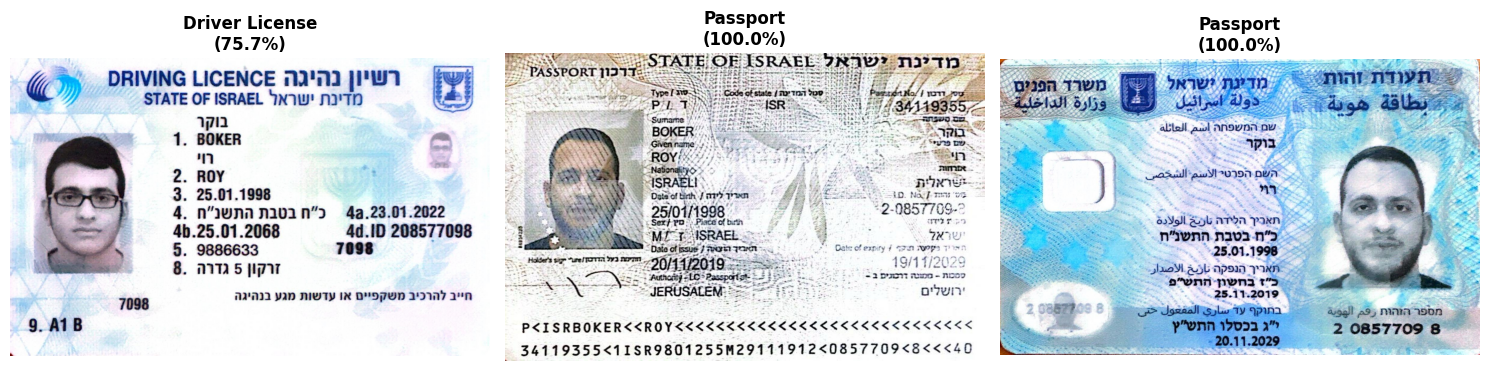


✅ Completed testing on 3 images


In [11]:
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

# Label mapping
label_map = {
    0: "ID Card",
    1: "Passport",
    2: "Driver License"
}

# Test images directory
test_dir = Path("/Users/roy-siftt/final-project/datasets/test")

# Find all JPEG images in test directory
test_images = list(test_dir.glob("*.jpeg")) + list(test_dir.glob("*.jpg")) + list(test_dir.glob("*.JPEG")) + list(test_dir.glob("*.JPG"))

print(f"Found {len(test_images)} images in test directory:")
for img_path in test_images:
    print(f"  - {img_path.name}")

if len(test_images) == 0:
    print("⚠️  No images found in test directory!")
else:
    # Ensure model is in eval mode
    model.eval()
    
    # Use the same transform as validation/test
    # (Assuming val_test_transform is defined - if not, we'll define it here)
    from torchvision import transforms
    
    test_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                           std=[0.229, 0.224, 0.225])
    ])
    
    # Process each image
    fig, axes = plt.subplots(1, len(test_images), figsize=(5*len(test_images), 5))
    if len(test_images) == 1:
        axes = [axes]
    
    for idx, img_path in enumerate(test_images):
        try:
            # Load and preprocess image
            img = Image.open(img_path).convert("RGB")
            img_tensor = test_transform(img).unsqueeze(0).to(device)
            
            # Make prediction
            with torch.no_grad():
                outputs = model(img_tensor)
                probabilities = F.softmax(outputs, dim=1)
                predicted_class = torch.argmax(outputs, dim=1).item()
                confidence = probabilities[0][predicted_class].item()
            
            # Display results
            print(f"\n{'='*60}")
            print(f"📸 Image: {img_path.name}")
            print(f"{'='*60}")
            print(f"🎯 Predicted Document Type: {label_map[predicted_class]}")
            print(f"📈 Confidence: {confidence*100:.2f}%")

            
            # Display image
            axes[idx].imshow(img)
            axes[idx].axis('off')
            axes[idx].set_title(f"{label_map[predicted_class]}\n({confidence*100:.1f}%)", 
                              fontsize=12, fontweight='bold')
            
        except Exception as e:
            print(f"\n❌ Error processing {img_path.name}: {e}")
            axes[idx].text(0.5, 0.5, f"Error:\n{str(e)[:30]}", 
                          ha='center', va='center', fontsize=10)
            axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Completed testing on {len(test_images)} images")

